In [1]:
import sympy as sym
from sympy.printing.dot import dotprint
import graphviz

In [2]:
def sympy_expr_to_graph(expr,fillcolor='lightblue'):
    """
    Convert a SymPy expression into a Graphviz Digraph for visualization.
    """
    #dot = graphviz.Digraph(comment="SymPy Expression Tree")
    dot = graphviz.Digraph(
        comment="SymPy Expression Tree",
        graph_attr={'bgcolor': 'transparent'},
        node_attr={'style': 'filled', 'fillcolor': fillcolor},
    )    
    visited = {}

    def add_node(e):
        # Use id(e) to uniquely identify nodes
        node_id = str(id(e))
        if node_id not in visited:
            visited[node_id] = True
            # Label: operator or symbol/number
            etype = type(e)
            etype_name = str(etype).split('.')[-1].split("'")[0]  #strip off only the fundamental not the whole class hierarchy
            label = str(e)
            new_label = etype_name+'\n'+label
            #print(new_label)
            dot.node(node_id, new_label)

            # Recursively add children
            if hasattr(e, 'args'):
                for arg in e.args:
                    child_id = add_node(arg)
                    dot.edge(node_id, child_id)
        return node_id

    add_node(expr)
    return dot


def graph_expr(expr,color='white'):
    styles = [(Basic, {'style': 'filled',
                       'fillcolor': color,
                       'shape': 'ellipse'})]
    dot_form = dotprint(expr, styles=styles)
    return graphviz.Source(dot_form)

def export_expression(expr,dpi_num,filename_no_suffix,file_format,fillcolor='White'):
    temp = setg(expr,fillcolor=fillcolor)
    temp.attr(dpi=str(dpi_num))
    temp.render(filename_no_suffix,format='png', cleanup=True)

In [3]:
a,b,c,d,e,f,i,n,r,s,t,v,x,y,z, G = sym.symbols('a:f i n r:t v x:z G')
mu = sym.Symbol('mu')
g  = sym.Function('g')
setg = sympy_expr_to_graph

# Case 1 - A Complicated linear expression in $\sin(x^2)$ with a dash of $\sin(y^2)$ and a fraction

a + b*sin(x**2)/2 + 3*c*sin(x**2)**2/4 + d*sin(x**4) + e*sin(y**2)**7 + 1/(a + x/c)

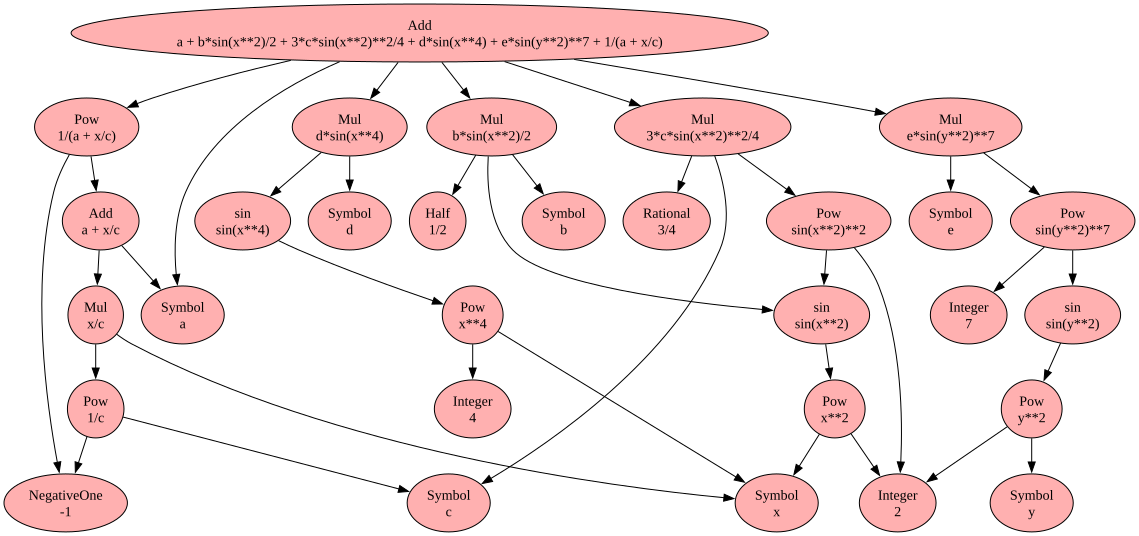

In [39]:
c1 = a + b/2*sym.sin(x**2) + 3*c/4*sym.sin(x**2)**2 + d*sym.sin(x**4) + e*sym.sin(y**2)**7 + 1/(a + x/c)
display(c1)
setg(c1,fillcolor="#FFB0B0")
#export_expression(c1,dpi_num=600,filename_no_suffix='A2D_05(May)_2026_c1',file_format='png',fillcolor="#FFB0B0")

In [40]:
for atom in c1.atoms():
    print(atom,'\t',type(atom))

2 	 <class 'sympy.core.numbers.Integer'>
4 	 <class 'sympy.core.numbers.Integer'>
7 	 <class 'sympy.core.numbers.Integer'>
1/2 	 <class 'sympy.core.numbers.Half'>
y 	 <class 'sympy.core.symbol.Symbol'>
b 	 <class 'sympy.core.symbol.Symbol'>
e 	 <class 'sympy.core.symbol.Symbol'>
a 	 <class 'sympy.core.symbol.Symbol'>
3/4 	 <class 'sympy.core.numbers.Rational'>
x 	 <class 'sympy.core.symbol.Symbol'>
c 	 <class 'sympy.core.symbol.Symbol'>
d 	 <class 'sympy.core.symbol.Symbol'>
-1 	 <class 'sympy.core.numbers.NegativeOne'>


In [41]:
queries = [sym.Add,sym.Mul,sym.Pow,sym.exp,sym.sin,x,sym.sin(x**2),sym.sin(x**2)**2,y**2,sym.Rational]
for query in queries:
    if hasattr(query,'__name__'):
        print(query.__name__,' (n):\t',c1.has(query),c1.find(query))
    elif callable(getattr(query,'__repr__',None)):
        print(query.__repr__(),' (r):\t',c1.has(query),c1.find(query))
    else:
        print(query,' ():\t',c1.has(query),c1.find(query))

Add  (n):	 True {a + b*sin(x**2)/2 + 3*c*sin(x**2)**2/4 + d*sin(x**4) + e*sin(y**2)**7 + 1/(a + x/c), a + x/c}
Mul  (n):	 True {x/c, 3*c*sin(x**2)**2/4, e*sin(y**2)**7, d*sin(x**4), b*sin(x**2)/2}
Pow  (n):	 True {y**2, sin(y**2)**7, x**2, 1/c, 1/(a + x/c), sin(x**2)**2, x**4}
exp  (n):	 False set()
sin  (n):	 True {sin(x**4), sin(x**2), sin(y**2)}
x  (r):	 True {x}
sin(x**2)  (r):	 True {sin(x**2)}
sin(x**2)**2  (r):	 True {sin(x**2)**2}
y**2  (r):	 True {y**2}
Rational  (n):	 True {2, 4, 7, 1/2, 3/4, -1}


# Case 2 - Looking at 'has' and 'find'

In [42]:
tree1 = mu/2/(a+b/2)
tree2 = mu/(2*a+b)
tree3 = mu/(2*(a+b/2))

In [51]:
display(tree1)
display(tree2)
display(tree3)
print('tree1 == tree2',tree1==tree2)
print('tree1 == tree3',tree1==tree3)
print('tree2 == tree3',tree2==tree3)
print('tree1.equals(tree2)',tree1.equals(tree2))
print('tree1.equals(tree3)',tree1.equals(tree3))
print('tree2.equals(tree3)',tree1.equals(tree2))
print('simplify(tree1-tree2)',sym.simplify(tree1-tree2))
print('simplify(tree1-tree3)',sym.simplify(tree1-tree3))
print('simplify(tree2-tree3)',sym.simplify(tree2-tree3))
setg(tree1,fillcolor='PaleGreen')
#export_expression(tree1,300,'tree1','png','PaleGreen')
setg(tree2,fillcolor='Plum')
#export_expression(tree2,300,'tree2','png','LightCyan')
setg(tree3,fillcolor='Yellow')
#export_expression(tree3,300,'tree3','png','LemonChiffon')
print(tree1.atoms())
print(tree2.atoms())
print(tree3.atoms())

mu/(2*(a + b/2))

mu/(2*a + b)

mu/(2*a + b)

tree1 == tree2 False
tree1 == tree3 False
tree2 == tree3 True
tree1.equals(tree2) True
tree1.equals(tree3) True
tree2.equals(tree3) True
simplify(tree1-tree2) 0
simplify(tree1-tree3) 0
simplify(tree2-tree3) 0
{1/2, b, a, mu, -1}
{2, b, a, mu, -1}
{2, b, a, mu, -1}


In [45]:
print('tree1.has(b)',tree1.has(b))
print('tree1.has(b/2)',tree1.has(b/2))
print('tree1.has(2*b)',tree1.has(2*b))
print('tree1.find(b)',tree1.find(b))
print('tree1.find(b/2)',tree1.find(b/2))

tree1.has(b) True
tree1.has(b/2) True
tree1.has(2*b) False
tree1.find(b) {b}
tree1.find(b/2) {b/2}


In [56]:
trees   = [tree1, tree2, tree3]
queries = [a,2*a,b,b/2]
for tree in trees:
    for query in queries:
        print(tree.__repr__()," has/hasn't ",query,tree.has(query))

mu/(2*(a + b/2))  has/hasn't  a True
mu/(2*(a + b/2))  has/hasn't  2*a False
mu/(2*(a + b/2))  has/hasn't  b True
mu/(2*(a + b/2))  has/hasn't  b/2 True
mu/(2*a + b)  has/hasn't  a True
mu/(2*a + b)  has/hasn't  2*a True
mu/(2*a + b)  has/hasn't  b True
mu/(2*a + b)  has/hasn't  b/2 False
mu/(2*a + b)  has/hasn't  a True
mu/(2*a + b)  has/hasn't  2*a True
mu/(2*a + b)  has/hasn't  b True
mu/(2*a + b)  has/hasn't  b/2 False
